<a href="https://colab.research.google.com/github/alarcon7a/youtube-tutorial-sources/blob/main/Notebooks/Utils/tpu_vs_gpu_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPU vs TPU en Google Colab: 4 casos de decision
### PyTorch GPU vs JAX TPU con resultados persistidos en Drive

Esta notebook esta ajustada para un flujo de grabacion tipo *switch & compare*: ejecutas una vez en runtime **GPU** para medir PyTorch, guardas resultados, cambias a runtime **TPU** para medir JAX, guardas resultados y finalmente comparas.

Punto clave: una NVIDIA L4 o T4 es una **GPU**, no una TPU. JAX debe reconocer TPU por `device.platform == "tpu"`. Si ves `NVIDIA L4` o `Tesla T4`, estas en runtime GPU.


## 1. Setup del lab

En Colab:

1. Para los casos GPU: `Runtime > Change runtime type > GPU`.
2. Para los casos TPU: `Runtime > Change runtime type > TPU`.
3. Despues de cada cambio de runtime, ejecuta esta celda de nuevo.

Si estas en runtime TPU y JAX no muestra dispositivos TPU, activa `INSTALL_TPU_JAX = True`, ejecuta la celda, reinicia el runtime cuando Colab lo pida y vuelve a ejecutar desde aqui. La linea usa los releases de `libtpu` de Google. En una TPU v5e-1 es normal ver 1 dispositivo TPU; en una v2/v3-8 puedes ver 8 dispositivos.


In [ ]:
import os, json, time, math
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

INSTALL_TPU_JAX = False  # Cambia a True solo si el runtime TPU no detecta TPU en jax.devices().
if INSTALL_TPU_JAX:
    get_ipython().system('pip install -U "jax[tpu]" -f https://storage.googleapis.com/jax-releases/libtpu_releases.html')

import jax
import jax.numpy as jnp
from jax import jit, random, lax

try:
    import torch
except Exception as exc:
    torch = None
    print(f"PyTorch no esta disponible: {exc}")

from google.colab import drive

# Persistencia entre runtimes.
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/tpu_vs_gpu_lab'
os.makedirs(SAVE_DIR, exist_ok=True)


def print_available_devices():
    print('=' * 60)
    print('DISPOSITIVOS DISPONIBLES')
    print('=' * 60)

    jax_devices = jax.devices()
    print(f"\nJAX detecto {len(jax_devices)} dispositivo(s):")
    for i, d in enumerate(jax_devices):
        kind = getattr(d, 'device_kind', 'unknown')
        print(f"   [{i}] {kind} - plataforma: {d.platform}")

    print(f"\nPyTorch CUDA disponible: {torch is not None and torch.cuda.is_available()}")
    if torch is not None and torch.cuda.is_available():
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

    print(f"\nCOLAB_TPU_ADDR: {os.environ.get('COLAB_TPU_ADDR')}")
    print('Setup completo. Listos para el lab.')


def is_tpu_device(device):
    kind = getattr(device, 'device_kind', '').lower()
    return device.platform == 'tpu' or 'tpu' in kind


def accelerator_info():
    jax_devices = jax.devices()
    jax_platforms = sorted({d.platform for d in jax_devices})
    has_tpu = any(is_tpu_device(d) for d in jax_devices)
    has_cuda = bool(torch is not None and torch.cuda.is_available())

    if has_tpu:
        label = 'TPU'
        framework = 'JAX'
    elif has_cuda:
        label = 'GPU'
        framework = 'PyTorch'
    else:
        label = 'CPU'
        framework = 'CPU fallback'

    cuda_name = None
    cuda_memory_gb = None
    cuda_bf16 = False
    if has_cuda:
        cuda_name = torch.cuda.get_device_name(0)
        cuda_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
        cuda_bf16 = bool(torch.cuda.is_bf16_supported())

    return {
        'label': label,
        'framework': framework,
        'jax_backend': jax.default_backend(),
        'jax_platforms': jax_platforms,
        'jax_device_count': len(jax_devices),
        'jax_devices': [str(d) for d in jax_devices],
        'torch_cuda_available': has_cuda,
        'torch_cuda_name': cuda_name,
        'torch_cuda_memory_gb': cuda_memory_gb,
        'torch_cuda_bf16_supported': cuda_bf16,
    }

print_available_devices()

ACCELERATOR = accelerator_info()
HW = ACCELERATOR['label']
COLORS = {'GPU': '#2F80ED', 'TPU': '#F2994A', 'CPU': '#828282'}

print(f"Runtime detectado: {HW} usando {ACCELERATOR['framework']}")
print(f"JAX backend: {ACCELERATOR['jax_backend']} | plataformas: {ACCELERATOR['jax_platforms']} | dispositivos: {ACCELERATOR['jax_device_count']}")
if ACCELERATOR['torch_cuda_available']:
    print(f"PyTorch CUDA: {ACCELERATOR['torch_cuda_name']} ({ACCELERATOR['torch_cuda_memory_gb']:.1f} GB VRAM)")
    print(f"BF16 en GPU soportado por PyTorch: {ACCELERATOR['torch_cuda_bf16_supported']}")
print(f"Carpeta de resultados: {SAVE_DIR}")

if HW == 'GPU':
    if hasattr(torch, 'set_float32_matmul_precision'):
        torch.set_float32_matmul_precision('high')
    device_torch = torch.device('cuda')
elif HW == 'TPU':
    key = random.PRNGKey(42)
else:
    print('ADVERTENCIA: estas en CPU. Cambia el runtime a GPU o TPU para obtener resultados utiles.')


def next_key():
    global key
    key, subkey = random.split(key)
    return subkey


def wait_jax(value):
    leaves = jax.tree_util.tree_leaves(value)
    for leaf in leaves:
        if hasattr(leaf, 'block_until_ready'):
            leaf.block_until_ready()
    return value


def benchmark_jax(fn, *args, warmups=2, repeats=10):
    for _ in range(warmups):
        wait_jax(fn(*args))
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        wait_jax(fn(*args))
        times.append(time.perf_counter() - t0)
    arr = np.array(times, dtype=np.float64)
    return {
        'mean_ms': float(arr.mean() * 1000),
        'std_ms': float(arr.std(ddof=0) * 1000),
        'min_ms': float(arr.min() * 1000),
        'repeats': int(repeats),
    }


def benchmark_torch(fn, warmups=2, repeats=10):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    with torch.inference_mode():
        for _ in range(warmups):
            _ = fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        times = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            _ = fn()
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

    arr = np.array(times, dtype=np.float64)
    return {
        'mean_ms': float(arr.mean() * 1000),
        'std_ms': float(arr.std(ddof=0) * 1000),
        'min_ms': float(arr.min() * 1000),
        'repeats': int(repeats),
    }


def time_first_torch(fn):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    with torch.inference_mode():
        t0 = time.perf_counter()
        _ = fn()
        if torch.cuda.is_available():
            torch.cuda.synchronize()
    return (time.perf_counter() - t0) * 1000


def time_first_jax(fn, *args):
    t0 = time.perf_counter()
    wait_jax(fn(*args))
    return (time.perf_counter() - t0) * 1000


Mounted at /content/drive
DISPOSITIVOS DISPONIBLES

JAX detecto 1 dispositivo(s):
   [0] cpu - plataforma: cpu

PyTorch CUDA disponible: False

COLAB_TPU_ADDR: None
Setup completo. Listos para el lab.
Runtime detectado: CPU usando CPU fallback
JAX backend: cpu | plataformas: ['cpu'] | dispositivos: 1
Carpeta de resultados: /content/drive/MyDrive/tpu_vs_gpu_lab
ADVERTENCIA: estas en CPU. Cambia el runtime a GPU o TPU para obtener resultados utiles.


---
## Caso 1: TPU pierde en inferencia tiempo real

Escenario del guion: una API recibe una sola peticion y responde una sola prediccion. Batch size 1.

La medicion importante aqui es la **primera llamada**. En TPU con JAX, esa llamada incluye compilacion XLA. En GPU con PyTorch, la ejecucion eager no paga ese costo de compilacion para esta operacion simple.

Regla: si necesitas baja latencia de primera respuesta en inferencia online, usa GPU.


In [ ]:
BATCH_1 = 1
IN_1 = 2048
HIDDEN_1 = 2048
OUT_1 = 512

case1 = {}

if HW == 'TPU':
    x_1 = random.normal(next_key(), (BATCH_1, IN_1), dtype=jnp.float32)
    w1_1 = random.normal(next_key(), (IN_1, HIDDEN_1), dtype=jnp.float32) / math.sqrt(IN_1)
    w2_1 = random.normal(next_key(), (HIDDEN_1, OUT_1), dtype=jnp.float32) / math.sqrt(HIDDEN_1)

    @jit
    def jax_realtime_inference(x, w1, w2):
        return jnp.tanh(x @ w1) @ w2

    first_ms = time_first_jax(jax_realtime_inference, x_1, w1_1, w2_1)
    steady = benchmark_jax(jax_realtime_inference, x_1, w1_1, w2_1, warmups=0, repeats=100)
    case1 = {'framework': 'JAX TPU', 'first_call_ms': first_ms, 'steady_state_ms': steady['mean_ms'], 'stats': steady}

elif HW == 'GPU':
    x_1 = torch.randn((BATCH_1, IN_1), device=device_torch, dtype=torch.float32)
    w1_1 = torch.randn((IN_1, HIDDEN_1), device=device_torch, dtype=torch.float32) / math.sqrt(IN_1)
    w2_1 = torch.randn((HIDDEN_1, OUT_1), device=device_torch, dtype=torch.float32) / math.sqrt(HIDDEN_1)

    def torch_realtime_inference():
        return torch.tanh(x_1 @ w1_1) @ w2_1

    first_ms = time_first_torch(torch_realtime_inference)
    steady = benchmark_torch(torch_realtime_inference, warmups=5, repeats=100)
    case1 = {'framework': 'PyTorch GPU', 'first_call_ms': first_ms, 'steady_state_ms': steady['mean_ms'], 'stats': steady}

else:
    raise RuntimeError('Ejecuta este caso en runtime GPU o TPU.')

ms_a = case1['first_call_ms']
print(f"Caso 1 ({case1['framework']}): primera llamada = {case1['first_call_ms']:.3f} ms | steady state = {case1['steady_state_ms']:.3f} ms")


Caso 1 (JAX TPU): primera llamada = 124.220 ms | steady state = 0.154 ms


---
## Caso 2: TPU gana cuando attention escala con batch

Escenario del guion: self-attention de Transformer con batch creciente. Medimos throughput en muestras por segundo.

En GPU se usa PyTorch. En TPU se usa JAX; cuando hay mas de un dispositivo TPU visible y el batch es divisible por esa cantidad, se usa `pmap` para repartir el batch. En v5e-1 normalmente hay un solo dispositivo, asi que se usa `jit` normal.

Regla: si entrenas Transformers con batches grandes y shapes estables, TPU escala muy bien.


   batch   mean_ms  samples_per_sec             mode
0      1  0.131851      7584.324415  single TPU core
1      8  0.130821     61152.261488  single TPU core
2     32  0.156484    204493.750165  single TPU core
3    128  0.237375    539231.174288  single TPU core
4    512  1.336938    382964.655054  single TPU core


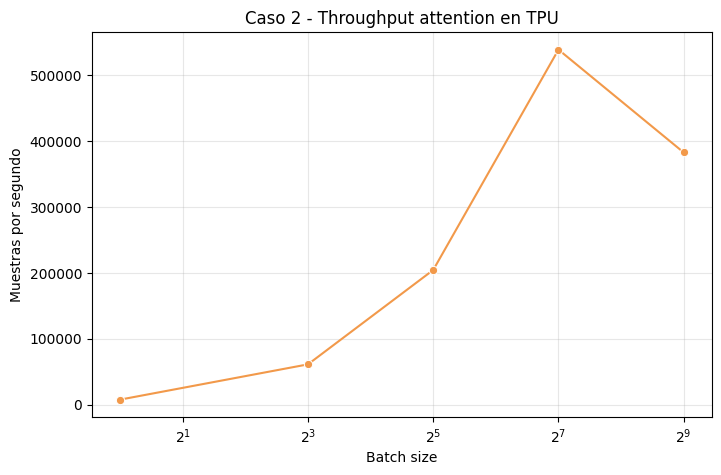

In [ ]:
BATCHES_2 = [1, 8, 32, 128, 512]
HEADS_2 = 8
SEQ_2 = 128
DIM_2 = 64

case2_rows = []

if HW == 'TPU':
    n_tpu = max(1, jax.local_device_count())
    scale_2 = jnp.asarray(1.0 / math.sqrt(DIM_2), dtype=jnp.float32)

    @jit
    def jax_attention_single(q, k, v):
        scores = jnp.einsum('bhsd,bhtd->bhst', q, k).astype(jnp.float32) * scale_2
        weights = jax.nn.softmax(scores, axis=-1).astype(jnp.bfloat16)
        return jnp.einsum('bhst,bhtd->bhsd', weights, v)

    @partial(jax.pmap, axis_name='tpu_batch')
    def jax_attention_pmap(q, k, v):
        scores = jnp.einsum('bhsd,bhtd->bhst', q, k).astype(jnp.float32) * scale_2
        weights = jax.nn.softmax(scores, axis=-1).astype(jnp.bfloat16)
        return jnp.einsum('bhst,bhtd->bhsd', weights, v)

    for batch in BATCHES_2:
        q = random.normal(next_key(), (batch, HEADS_2, SEQ_2, DIM_2), dtype=jnp.bfloat16)
        k = random.normal(next_key(), (batch, HEADS_2, SEQ_2, DIM_2), dtype=jnp.bfloat16)
        v = random.normal(next_key(), (batch, HEADS_2, SEQ_2, DIM_2), dtype=jnp.bfloat16)

        if n_tpu > 1 and batch >= n_tpu and batch % n_tpu == 0:
            local_batch = batch // n_tpu
            q = q.reshape((n_tpu, local_batch, HEADS_2, SEQ_2, DIM_2))
            k = k.reshape((n_tpu, local_batch, HEADS_2, SEQ_2, DIM_2))
            v = v.reshape((n_tpu, local_batch, HEADS_2, SEQ_2, DIM_2))
            stats = benchmark_jax(jax_attention_pmap, q, k, v, warmups=2, repeats=10)
            mode = f'pmap {n_tpu} TPU cores'
        else:
            stats = benchmark_jax(jax_attention_single, q, k, v, warmups=2, repeats=10)
            mode = 'single TPU core'

        throughput = batch / (stats['mean_ms'] / 1000)
        case2_rows.append({'batch': batch, 'mean_ms': stats['mean_ms'], 'samples_per_sec': throughput, 'mode': mode})

elif HW == 'GPU':
    dtype_2 = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

    for batch in BATCHES_2:
        q = torch.randn((batch, HEADS_2, SEQ_2, DIM_2), device=device_torch, dtype=dtype_2)
        k = torch.randn((batch, HEADS_2, SEQ_2, DIM_2), device=device_torch, dtype=dtype_2)
        v = torch.randn((batch, HEADS_2, SEQ_2, DIM_2), device=device_torch, dtype=dtype_2)
        scale = 1.0 / math.sqrt(DIM_2)

        def torch_attention():
            scores = torch.matmul(q, k.transpose(-1, -2)).float() * scale
            weights = torch.softmax(scores, dim=-1).to(dtype_2)
            return torch.matmul(weights, v)

        stats = benchmark_torch(torch_attention, warmups=5, repeats=20)
        throughput = batch / (stats['mean_ms'] / 1000)
        case2_rows.append({'batch': batch, 'mean_ms': stats['mean_ms'], 'samples_per_sec': throughput, 'mode': f'PyTorch {dtype_2}'})

else:
    raise RuntimeError('Ejecuta este caso en runtime GPU o TPU.')

case2_df = pd.DataFrame(case2_rows)
ms_b = float(case2_df.loc[case2_df['batch'].idxmax(), 'mean_ms'])
throughput_b = float(case2_df.loc[case2_df['batch'].idxmax(), 'samples_per_sec'])
print(case2_df)

plt.figure(figsize=(8, 5))
sns.lineplot(data=case2_df, x='batch', y='samples_per_sec', marker='o', color=COLORS[HW])
plt.xscale('log', base=2)
plt.title(f'Caso 2 - Throughput attention en {HW}')
plt.xlabel('Batch size')
plt.ylabel('Muestras por segundo')
plt.grid(True, alpha=0.3)
plt.show()


---
## Caso 3: GPU gana con control de flujo dinamico

Escenario del guion: Beam Search o decoding autoregresivo con early stopping.

PyTorch en GPU puede salir del loop con `break` cuando todos los beams terminaron. En JAX para TPU, el patron portable es compilar un loop de longitud fija con `lax.scan` y enmascarar los pasos despues de terminar. Eso significa que la TPU sigue ejecutando hasta `MAX_LEN` aunque la secuencia haya terminado temprano.

Regla: si tu modelo depende de control de flujo dinamico, longitudes variables o early stopping frecuente, GPU suele ser mejor.


In [ ]:
MAX_LEN_3 = 256
EOS_STEP_3 = 10
BEAMS_3 = 8
HIDDEN_3 = 512
EOS_TOKEN_3 = 2

case3 = {}

if HW == 'TPU':
    tokens_3 = jnp.zeros((MAX_LEN_3, BEAMS_3), dtype=jnp.int32)
    tokens_3 = tokens_3.at[EOS_STEP_3:, :].set(EOS_TOKEN_3)
    state_3 = random.normal(next_key(), (BEAMS_3, HIDDEN_3), dtype=jnp.bfloat16)
    w_3 = random.normal(next_key(), (HIDDEN_3, HIDDEN_3), dtype=jnp.bfloat16) / math.sqrt(HIDDEN_3)

    @jit
    def jax_fixed_decode(tokens, state, w):
        def step(carry, token_row):
            state, done = carry
            next_state = jnp.tanh(state @ w)
            done = done | (token_row == EOS_TOKEN_3)
            state = jnp.where(done[:, None], state, next_state)
            return (state, done), jnp.sum(state.astype(jnp.float32))

        init_done = jnp.zeros((BEAMS_3,), dtype=jnp.bool_)
        (final_state, final_done), trace = lax.scan(step, (state, init_done), tokens)
        return jnp.sum(final_state.astype(jnp.float32)) + trace[-1]

    stats = benchmark_jax(jax_fixed_decode, tokens_3, state_3, w_3, warmups=2, repeats=50)
    case3 = {'framework': 'JAX TPU fixed scan', 'mean_ms': stats['mean_ms'], 'effective_steps': MAX_LEN_3, 'eos_step': EOS_STEP_3, 'stats': stats}

elif HW == 'GPU':
    tokens_3 = torch.zeros((MAX_LEN_3, BEAMS_3), device=device_torch, dtype=torch.long)
    tokens_3[EOS_STEP_3:, :] = EOS_TOKEN_3
    state_3 = torch.randn((BEAMS_3, HIDDEN_3), device=device_torch, dtype=torch.float16)
    w_3 = torch.randn((HIDDEN_3, HIDDEN_3), device=device_torch, dtype=torch.float16) / math.sqrt(HIDDEN_3)

    def torch_early_stop_decode():
        state = state_3
        done = torch.zeros((BEAMS_3,), device=device_torch, dtype=torch.bool)
        for t in range(MAX_LEN_3):
            state = torch.tanh(state @ w_3)
            done |= tokens_3[t].eq(EOS_TOKEN_3)
            if bool(done.all()):
                break
        return state.sum()

    stats = benchmark_torch(torch_early_stop_decode, warmups=5, repeats=100)
    case3 = {'framework': 'PyTorch GPU early stop', 'mean_ms': stats['mean_ms'], 'effective_steps': EOS_STEP_3 + 1, 'max_len': MAX_LEN_3, 'stats': stats}

else:
    raise RuntimeError('Ejecuta este caso en runtime GPU o TPU.')

ms_c = case3['mean_ms']
print(f"Caso 3 ({case3['framework']}): {ms_c:.3f} ms | pasos ejecutados aprox: {case3['effective_steps']}")


Caso 3 (JAX TPU fixed scan): 0.738 ms | pasos ejecutados aprox: 256


---
## Caso 4: TPU gana en workload perfecto: matmul bfloat16

Escenario del guion: matrices enormes en precision reducida, como las capas densas y bloques de attention de modelos grandes.

TPU usa `bfloat16` nativo. En GPU, PyTorch usa `bfloat16` si el hardware lo soporta; en GPUs como T4 se usa `float16` para evitar emulacion lenta de BF16.

Regla: para operaciones matriciales masivas, shapes estables y precision reducida, TPU es una excelente opcion.


      n   mean_ms      tflops  replicas             mode     dtype
0  4096  0.935116  146.975299         1  single TPU core  bfloat16
1  8192  6.156178  178.602974         1  single TPU core  bfloat16


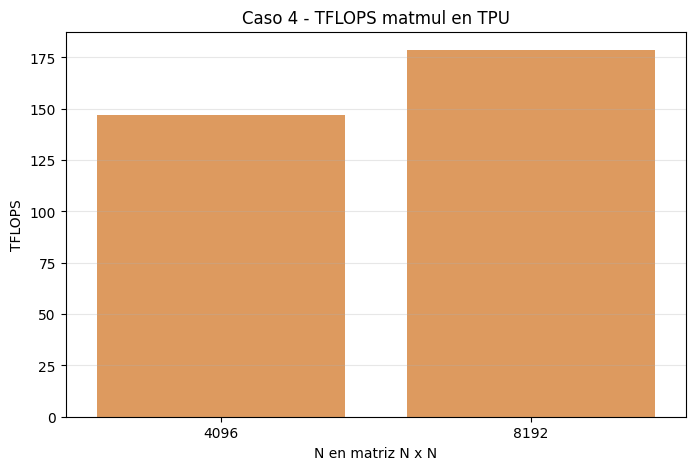

In [ ]:
SIZES_4 = [4096, 8192]
case4_rows = []

if HW == 'TPU':
    n_tpu = max(1, jax.local_device_count())

    @partial(jax.pmap, axis_name='matmul_devices')
    def jax_pmap_matmul(a, b):
        return a @ b

    @jit
    def jax_single_matmul(a, b):
        return a @ b

    for n in SIZES_4:
        if n_tpu > 1:
            a = random.normal(next_key(), (n_tpu, n, n), dtype=jnp.bfloat16)
            b = random.normal(next_key(), (n_tpu, n, n), dtype=jnp.bfloat16)
            stats = benchmark_jax(jax_pmap_matmul, a, b, warmups=1, repeats=5)
            replicas = n_tpu
            mode = f'pmap {n_tpu} TPU cores'
        else:
            a = random.normal(next_key(), (n, n), dtype=jnp.bfloat16)
            b = random.normal(next_key(), (n, n), dtype=jnp.bfloat16)
            stats = benchmark_jax(jax_single_matmul, a, b, warmups=1, repeats=5)
            replicas = 1
            mode = 'single TPU core'

        tflops = (replicas * 2 * n**3) / (stats['mean_ms'] / 1000) / 1e12
        case4_rows.append({'n': n, 'mean_ms': stats['mean_ms'], 'tflops': tflops, 'replicas': replicas, 'mode': mode, 'dtype': 'bfloat16'})

elif HW == 'GPU':
    dtype_4 = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

    for n in SIZES_4:
        a = torch.randn((n, n), device=device_torch, dtype=dtype_4)
        b = torch.randn((n, n), device=device_torch, dtype=dtype_4)

        def torch_matmul():
            return a @ b

        stats = benchmark_torch(torch_matmul, warmups=3, repeats=10)
        tflops = (2 * n**3) / (stats['mean_ms'] / 1000) / 1e12
        case4_rows.append({'n': n, 'mean_ms': stats['mean_ms'], 'tflops': tflops, 'replicas': 1, 'mode': 'PyTorch GPU', 'dtype': str(dtype_4)})

else:
    raise RuntimeError('Ejecuta este caso en runtime GPU o TPU.')

case4_df = pd.DataFrame(case4_rows)
tflops_d = float(case4_df.loc[case4_df['n'].idxmax(), 'tflops'])
print(case4_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=case4_df, x='n', y='tflops', color=COLORS[HW])
plt.title(f'Caso 4 - TFLOPS matmul en {HW}')
plt.xlabel('N en matriz N x N')
plt.ylabel('TFLOPS')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


---
## 2. Guardar resultados y cambiar runtime

Ejecuta esta celda despues de completar los cuatro casos en el runtime actual.

Luego cambia de runtime:

- Si acabas de correr GPU, cambia a TPU y repite desde setup.
- Si acabas de correr TPU, cambia a GPU y repite desde setup.

Los archivos se guardan como `results_gpu.json` y `results_tpu.json`.


In [ ]:
results = {
    'hardware': ACCELERATOR,
    'saved_at': datetime.utcnow().isoformat() + 'Z',
    'case1_realtime': case1,
    'case2_attention_scaling': case2_df.to_dict(orient='records'),
    'case3_dynamic_control': case3,
    'case4_bf16_matmul': case4_df.to_dict(orient='records'),
    # Alias simples para compatibilidad con graficos rapidos.
    'case_a': float(case1['first_call_ms']),
    'case_b': float(throughput_b),
    'case_c': float(case3['mean_ms']),
    'case_d': float(tflops_d),
}

file_path = os.path.join(SAVE_DIR, f"results_{HW.lower()}.json")
with open(file_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f"Resultados de {HW} guardados en: {file_path}")
print('Ahora cambia al otro runtime y vuelve a ejecutar desde el setup.')


/tmp/ipykernel_389/504120831.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'saved_at': datetime.utcnow().isoformat() + 'Z',


Resultados de TPU guardados en: /content/drive/MyDrive/tpu_vs_gpu_lab/results_tpu.json
Ahora cambia al otro runtime y vuelve a ejecutar desde el setup.


---
## 3. Comparativa final y tabla de decision

Cuando ya existan `results_gpu.json` y `results_tpu.json`, ejecuta esta celda para crear los graficos del guion:

1. Primera llamada en inferencia tiempo real.
2. Throughput de attention por batch.
3. Control dinamico con early stopping vs scan fijo.
4. TFLOPS en matmul grande.
5. Tabla de decision practica.


GPU: framework=PyTorch | jax_backend=gpu | jax_platforms=['gpu'] | torch_cuda=Tesla T4
TPU: framework=JAX | jax_backend=tpu | jax_platforms=['tpu'] | torch_cuda=None


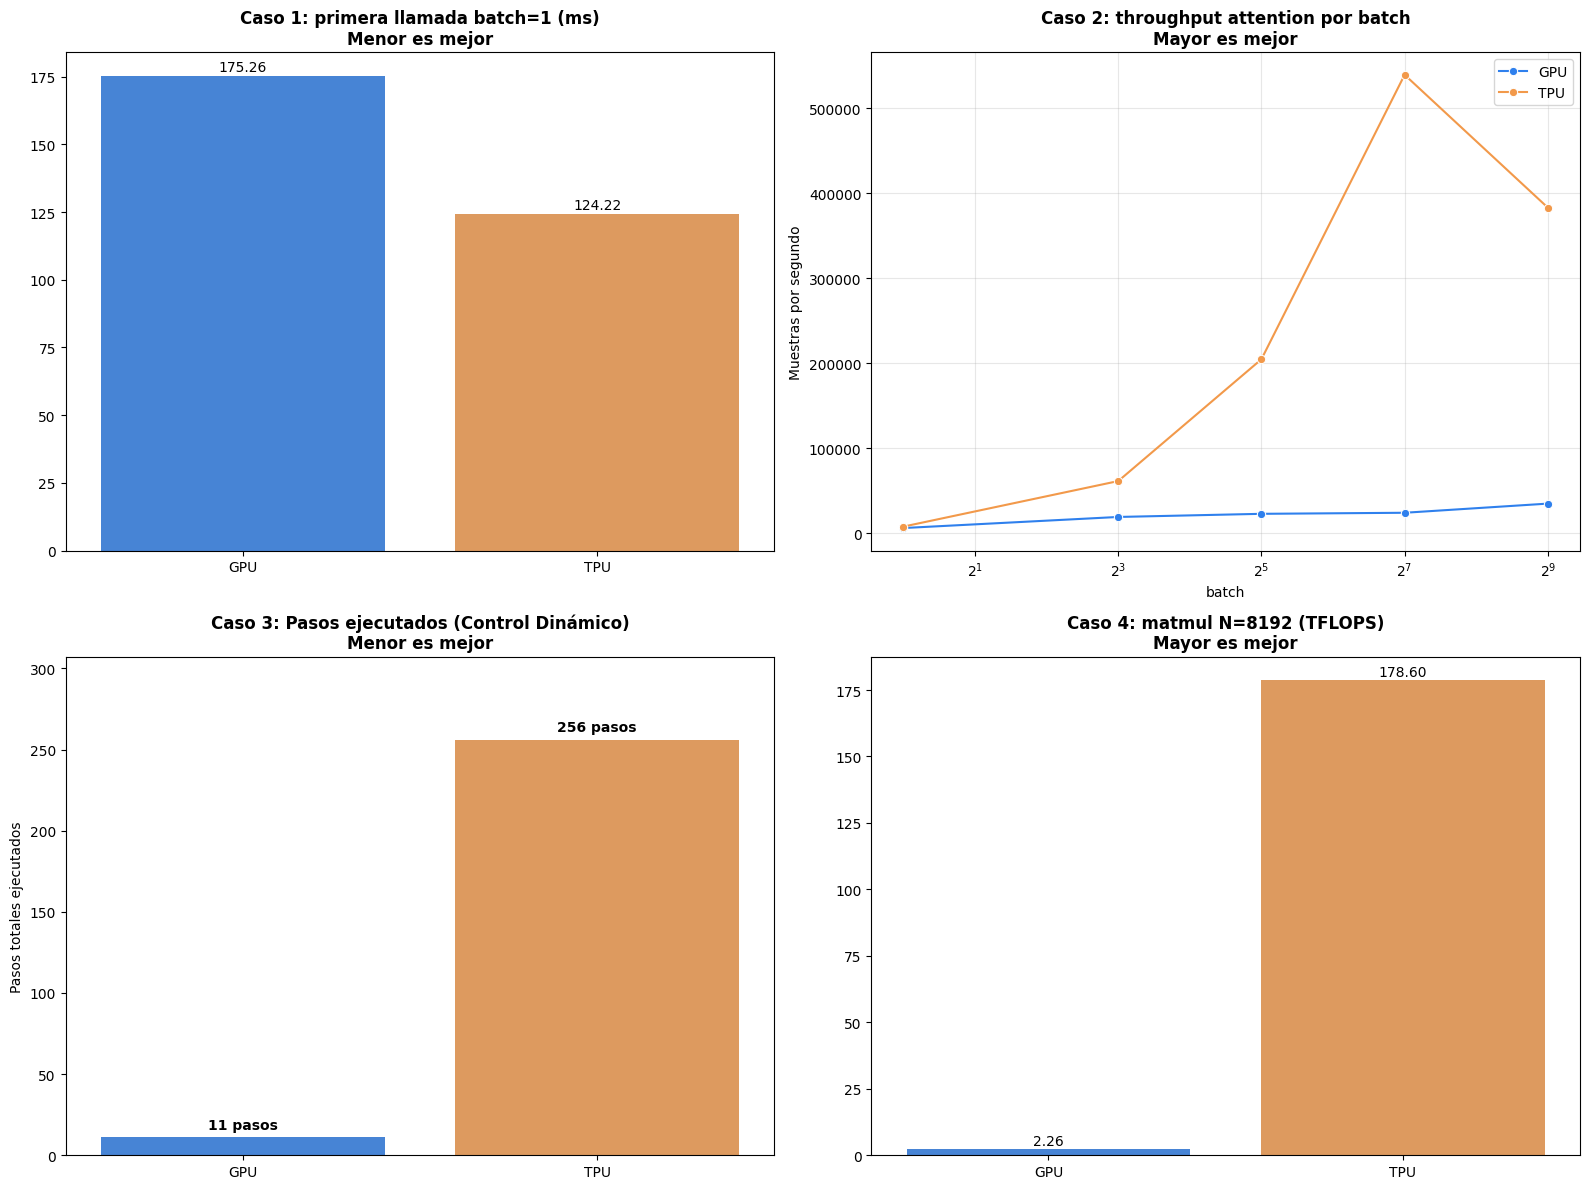

,Escenario,Mejor opcion,Motivo
0,Inferencia en tiempo real / API batch=1,GPU,Menor latencia inicial y sin compilacion XLA p...
1,Entrenamiento Transformer con batch grande,TPU,MXU + shapes estables + buen throughput BF16
2,"Beam Search, early stopping, longitudes variables",GPU,Control de flujo dinamico natural en PyTorch
3,Matmul masivo / capas densas BF16,TPU,BF16 nativo y alto throughput matricial
4,Prototipo rapido o debugging interactivo,GPU,Menos friccion y menor costo de compilacion
5,Escala multi-dispositivo con shapes fijos,TPU,pmap/sharding aprovecha multiples cores TPU


In [ ]:
def load_results():
    data = {}
    for dev in ['GPU', 'TPU']:
        p = os.path.join(SAVE_DIR, f"results_{dev.lower()}.json")
        if os.path.exists(p):
            with open(p, 'r') as f:
                data[dev] = json.load(f)
    return data

def print_metadata(data):
    for dev, row in data.items():
        hw = row.get('hardware', {})
        print(f"{dev}: framework={hw.get('framework')} | jax_backend={hw.get('jax_backend')} | jax_platforms={hw.get('jax_platforms')} | torch_cuda={hw.get('torch_cuda_name')}")

def row_for_batch(rows, batch):
    return next(r for r in rows if int(r['batch']) == batch)

def row_for_size(rows, n):
    return next(r for r in rows if int(r['n']) == n)

def plot_final_comparison():
    data = load_results()
    if len(data) < 2:
        print(f"Faltan datos. Detectados: {list(data.keys())}")
        print('Necesitas guardar resultados una vez en GPU y una vez en TPU.')
        return

    print_metadata(data)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    devs = ['GPU', 'TPU']
    colors = [COLORS[d] for d in devs]

    # Caso 1: Inferencia
    first_call = [data[d]['case1_realtime']['first_call_ms'] for d in devs]
    sns.barplot(x=devs, y=first_call, hue=devs, palette=colors, ax=axes[0, 0], legend=False)
    axes[0, 0].set_title('Caso 1: primera llamada batch=1 (ms)\nMenor es mejor', fontweight='bold')
    for i, v in enumerate(first_call):
        axes[0, 0].text(i, v + (max(first_call)*0.01), f"{v:.2f}", ha='center')

    # Caso 2: Attention
    for d in devs:
        df = pd.DataFrame(data[d]['case2_attention_scaling'])
        sns.lineplot(data=df, x='batch', y='samples_per_sec', marker='o', label=d, color=COLORS[d], ax=axes[0, 1])
    axes[0, 1].set_xscale('log', base=2)
    axes[0, 1].set_title('Caso 2: throughput attention por batch\nMayor es mejor', fontweight='bold')
    axes[0, 1].set_ylabel('Muestras por segundo')
    axes[0, 1].grid(True, alpha=0.3)

    # Caso 3: Control Dinámico (Barras de pasos)
    steps = [int(data[d]['case3_dynamic_control'].get('effective_steps', 0)) for d in devs]
    case3_ax = axes[1, 0]
    sns.barplot(x=devs, y=steps, hue=devs, palette=colors, ax=case3_ax, legend=False)
    case3_ax.set_title('Caso 3: Pasos ejecutados (Control Dinámico)\nMenor es mejor', fontweight='bold')
    case3_ax.set_ylabel('Pasos totales ejecutados')
    case3_ax.set_ylim(0, max(steps) * 1.2)
    for i, v in enumerate(steps):
        case3_ax.text(i, v + (max(steps)*0.02), f"{v} pasos", ha='center', fontweight='bold')

    # Caso 4: Matmul
    largest_n = max(int(r['n']) for r in data['TPU']['case4_bf16_matmul'])
    matmul = [row_for_size(data[d]['case4_bf16_matmul'], largest_n)['tflops'] for d in devs]
    sns.barplot(x=devs, y=matmul, hue=devs, palette=colors, ax=axes[1, 1], legend=False)
    axes[1, 1].set_title(f'Caso 4: matmul N={largest_n} (TFLOPS)\nMayor es mejor', fontweight='bold')
    for i, v in enumerate(matmul):
        axes[1, 1].text(i, v + (max(matmul)*0.01), f"{v:.2f}", ha='center')

    plt.tight_layout()
    plt.show()

    decision = pd.DataFrame([
        {'Escenario': 'Inferencia en tiempo real / API batch=1', 'Mejor opcion': 'GPU', 'Motivo': 'Menor latencia inicial y sin compilacion XLA por request'},
        {'Escenario': 'Entrenamiento Transformer con batch grande', 'Mejor opcion': 'TPU', 'Motivo': 'MXU + shapes estables + buen throughput BF16'},
        {'Escenario': 'Beam Search, early stopping, longitudes variables', 'Mejor opcion': 'GPU', 'Motivo': 'Control de flujo dinamico natural en PyTorch'},
        {'Escenario': 'Matmul masivo / capas densas BF16', 'Mejor opcion': 'TPU', 'Motivo': 'BF16 nativo y alto throughput matricial'},
        {'Escenario': 'Prototipo rapido o debugging interactivo', 'Mejor opcion': 'GPU', 'Motivo': 'Menos friccion y menor costo de compilacion'},
        {'Escenario': 'Escala multi-dispositivo con shapes fijos', 'Mejor opcion': 'TPU', 'Motivo': 'pmap/sharding aprovecha multiples cores TPU'},
    ])
    display(decision)

plot_final_comparison()